# Mathematical Transformation

## Function Transform

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

In [2]:
import scipy.stats as stats
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [5]:
df = pd.read_csv("DATASET/titanic.csv",usecols=['Age','Fare','Survived'])
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [6]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [7]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_7375/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [8]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [9]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [10]:
X = df.iloc[:,1:3]
# : before the comma means"select all rows."1:3 after the comma means
# "select columns from index 1 up to,
# but not including, index 3".
# This extracts Column 1 and Column 2 from your DataFrame

y = df.iloc[:,0]
# :  before the comma means"select all rows."0 after the comma means 
# "select only the first column".
# This extracts Column 0 as your target Series.



In [11]:
# split the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

/tmp/ipykernel_7375/134754205.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


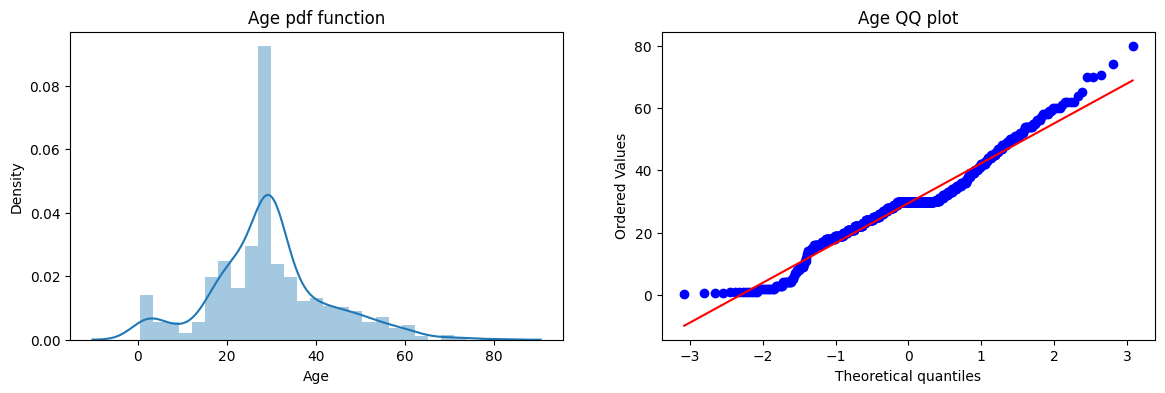

In [12]:
# plot the data for Age column
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age pdf function')

plt.subplot(122)
# QQ plot
stats.probplot(X_train['Age'],dist ='norm',plot =plt)
plt.title('Age QQ plot')
plt.show()

/tmp/ipykernel_7375/2203341847.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


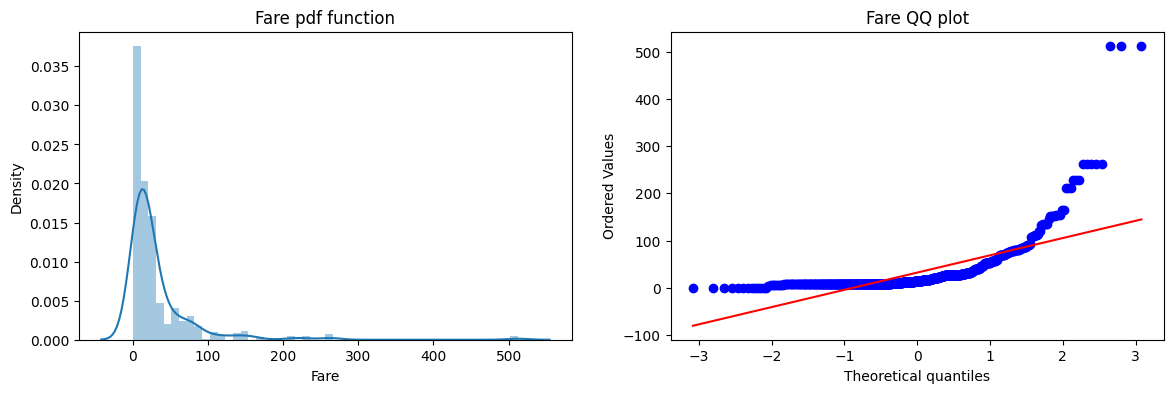

In [13]:
# plot the data for Fare column
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare pdf function')

plt.subplot(122)
# QQ plot
stats.probplot(X_train['Fare'],dist ='norm',plot =plt)
plt.title('Fare QQ plot')
plt.show()

In [14]:
# train model without transform
model_1 = DecisionTreeClassifier()
model_2 = LogisticRegression()

model_1.fit(X_train,y_train)
model_2.fit(X_train,y_train)

y_pred_1 = model_1.predict(X_test)
y_pred_2 = model_2.predict(X_test)

print("Acuuracy of Model 1(decision tree) :",accuracy_score(y_test,y_pred_1))
print("Acuuracy of Model 2(Logestic reg):",accuracy_score(y_test,y_pred_2))


Acuuracy of Model 1(decision tree) : 0.6816143497757847
Acuuracy of Model 2(Logestic reg): 0.6636771300448431


### 1.log transform

In [15]:
tra = FunctionTransformer(func=np.log1p)

# apply transform on training data
X_train_tra =tra.fit_transform(X_train)
X_test_tra= tra.transform(X_test)

model_1 =DecisionTreeClassifier()
model_2 =LogisticRegression()

model_1.fit(X_train_tra,y_train)
model_2.fit(X_train_tra,y_train)

y_pred_1 = model_1.predict(X_test_tra)
y_pred_2 = model_2.predict(X_test_tra)

print("Acuuracy of Model 1(decision tree) :",accuracy_score(y_test,y_pred_1))
print("Acuuracy of Model 2(logistic reg) :",accuracy_score(y_test,y_pred_2))


Acuuracy of Model 1(decision tree) : 0.6905829596412556
Acuuracy of Model 2(logistic reg) : 0.6816143497757847


In [16]:
# Apply cross val score to see the actual accuracy
X_tra =tra.fit_transform(X)

model_1 =DecisionTreeClassifier()
model_2 =LogisticRegression()

print('Decison Tree:',np.mean(cross_val_score(model_1, X_tra,y, scoring='accuracy',cv=10)))
print('Logestic reg:',np.mean(cross_val_score(model_2, X_tra,y,  scoring='accuracy',cv=10)))

Decison Tree: 0.6487765293383271
Logestic reg: 0.678027465667915


Text(0.5, 1.0, 'Fare After log transform')

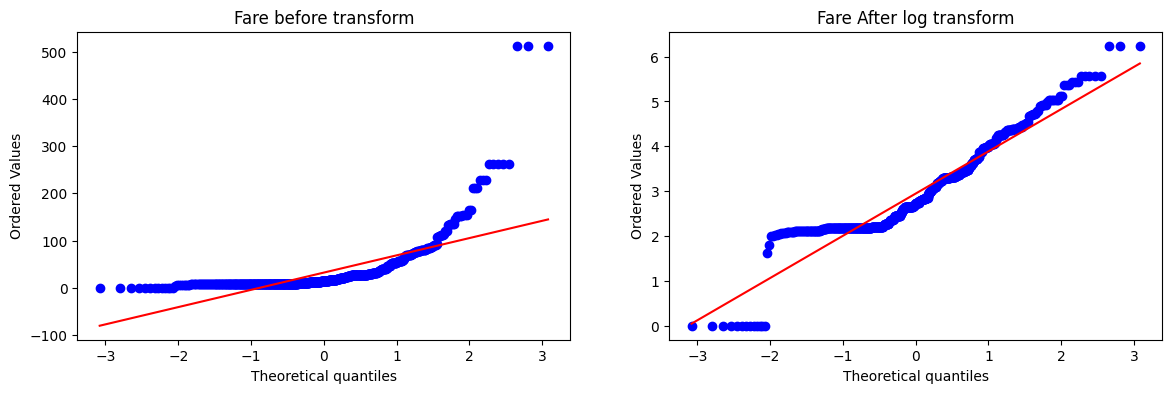

In [17]:
# plot the before and after apply the transform
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'], dist ='norm',plot =plt)
plt.title('Fare before transform')


plt.subplot(122)
stats.probplot(X_train_tra['Fare'],dist='norm',plot =plt)
plt.title('Fare After log transform')

Text(0.5, 1.0, 'Age After log transform')

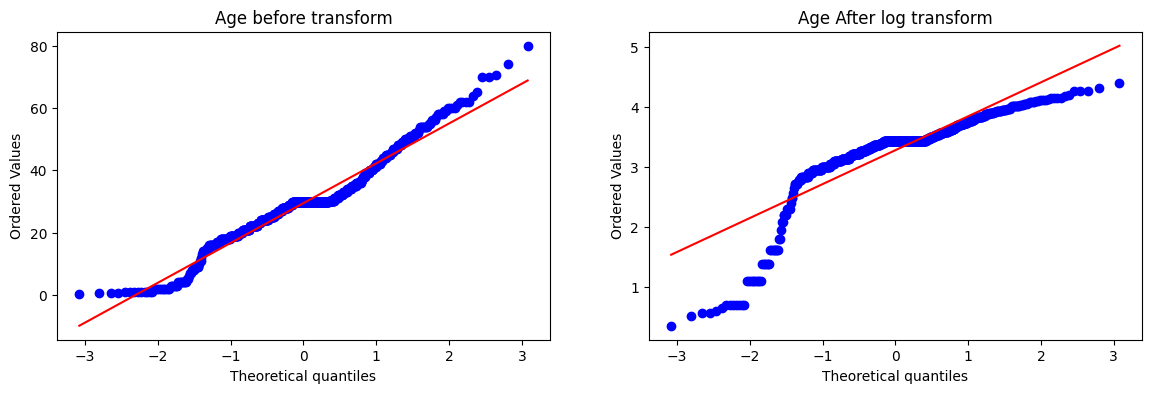

In [18]:
# plot the before and after apply the transform
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'], dist ='norm',plot =plt)
plt.title('Age before transform')


plt.subplot(122)
stats.probplot(X_train_tra['Age'],dist='norm',plot =plt)
plt.title('Age After log transform')

In [19]:
# apply transform on on the Fare , age pe mat karo
tra_2 = ColumnTransformer([
    ('log transform',FunctionTransformer(np.log1p),['Fare'])
], remainder='passthrough')

X_train_tra2 =tra_2.fit_transform(X_train)
X_test_tra2= tra_2.transform(X_test)

model_1 = DecisionTreeClassifier()
model_2 =LogisticRegression()

model_1.fit(X_train_tra2,y_train)
model_2.fit(X_train_tra2,y_train)

y_pred_dt =model_1.predict(X_test_tra2)
y_pred_lr=model_2.predict(X_test_tra2)

print("Accuracy decision tree :",accuracy_score(y_test,y_pred_dt))
print("Accuracy Logistic reg :",accuracy_score(y_test,y_pred_lr))

Accuracy decision tree : 0.6860986547085202
Accuracy Logistic reg : 0.672645739910314


In [20]:
# now apply cross val score on above 
X_transformed2 = tra_2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))


LR 0.6712609238451936
DT 0.6577153558052433


### 2.Reciprocal transform

In [21]:
# reciprocal transform

df['Age_reciprocal'] =1/df['Age']
print(df)

     Survived        Age     Fare  Age_reciprocal
0           0  22.000000   7.2500        0.045455
1           1  38.000000  71.2833        0.026316
2           1  26.000000   7.9250        0.038462
3           1  35.000000  53.1000        0.028571
4           0  35.000000   8.0500        0.028571
..        ...        ...      ...             ...
886         0  27.000000  13.0000        0.037037
887         1  19.000000  30.0000        0.052632
888         0  29.699118  23.4500        0.033671
889         1  26.000000  30.0000        0.038462
890         0  32.000000   7.7500        0.031250

[891 rows x 4 columns]


In [22]:
# square root transform

df['Age_squart'] =np.sqrt(df['Age'])
print(df)

     Survived        Age     Fare  Age_reciprocal  Age_squart
0           0  22.000000   7.2500        0.045455    4.690416
1           1  38.000000  71.2833        0.026316    6.164414
2           1  26.000000   7.9250        0.038462    5.099020
3           1  35.000000  53.1000        0.028571    5.916080
4           0  35.000000   8.0500        0.028571    5.916080
..        ...        ...      ...             ...         ...
886         0  27.000000  13.0000        0.037037    5.196152
887         1  19.000000  30.0000        0.052632    4.358899
888         0  29.699118  23.4500        0.033671    5.449690
889         1  26.000000  30.0000        0.038462    5.099020
890         0  32.000000   7.7500        0.031250    5.656854

[891 rows x 5 columns]


In [23]:
# cube root transform
df['Age_cuberoot'] =np.cbrt(df['Age'])
print(df)

     Survived        Age     Fare  Age_reciprocal  Age_squart  Age_cuberoot
0           0  22.000000   7.2500        0.045455    4.690416      2.802039
1           1  38.000000  71.2833        0.026316    6.164414      3.361975
2           1  26.000000   7.9250        0.038462    5.099020      2.962496
3           1  35.000000  53.1000        0.028571    5.916080      3.271066
4           0  35.000000   8.0500        0.028571    5.916080      3.271066
..        ...        ...      ...             ...         ...           ...
886         0  27.000000  13.0000        0.037037    5.196152      3.000000
887         1  19.000000  30.0000        0.052632    4.358899      2.668402
888         0  29.699118  23.4500        0.033671    5.449690      3.096810
889         1  26.000000  30.0000        0.038462    5.099020      2.962496
890         0  32.000000   7.7500        0.031250    5.656854      3.174802

[891 rows x 6 columns]


In [24]:
# square transform
df['Age_square'] =np.square(df['Age'])
print(df)

     Survived        Age     Fare  Age_reciprocal  Age_squart  Age_cuberoot  \
0           0  22.000000   7.2500        0.045455    4.690416      2.802039   
1           1  38.000000  71.2833        0.026316    6.164414      3.361975   
2           1  26.000000   7.9250        0.038462    5.099020      2.962496   
3           1  35.000000  53.1000        0.028571    5.916080      3.271066   
4           0  35.000000   8.0500        0.028571    5.916080      3.271066   
..        ...        ...      ...             ...         ...           ...   
886         0  27.000000  13.0000        0.037037    5.196152      3.000000   
887         1  19.000000  30.0000        0.052632    4.358899      2.668402   
888         0  29.699118  23.4500        0.033671    5.449690      3.096810   
889         1  26.000000  30.0000        0.038462    5.099020      2.962496   
890         0  32.000000   7.7500        0.031250    5.656854      3.174802   

      Age_square  
0     484.000000  
1    1444.000

In [25]:
# exponential transform
df['Age_exp'] =np.exp(df['Age'])
print(df)

     Survived        Age     Fare  Age_reciprocal  Age_squart  Age_cuberoot  \
0           0  22.000000   7.2500        0.045455    4.690416      2.802039   
1           1  38.000000  71.2833        0.026316    6.164414      3.361975   
2           1  26.000000   7.9250        0.038462    5.099020      2.962496   
3           1  35.000000  53.1000        0.028571    5.916080      3.271066   
4           0  35.000000   8.0500        0.028571    5.916080      3.271066   
..        ...        ...      ...             ...         ...           ...   
886         0  27.000000  13.0000        0.037037    5.196152      3.000000   
887         1  19.000000  30.0000        0.052632    4.358899      2.668402   
888         0  29.699118  23.4500        0.033671    5.449690      3.096810   
889         1  26.000000  30.0000        0.038462    5.099020      2.962496   
890         0  32.000000   7.7500        0.031250    5.656854      3.174802   

      Age_square       Age_exp  
0     484.000000  

In [26]:
# create a general function to apply any transform

def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    tra =ColumnTransformer([
        ('log',FunctionTransformer(transform),['Fare'])
    ],remainder='passthrough')

    X_trans = tra.fit_transform(X)

    model =LogisticRegression()
    print('Accuracy',np.mean(cross_val_score(model,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize =(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'],dist ='norm',plot =plt)
    plt.title('Fare befor transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0],dist ='norm',plot =plt)
    plt.title('Fare After transform')

    plt.show()

Accuracy 0.6712609238451936


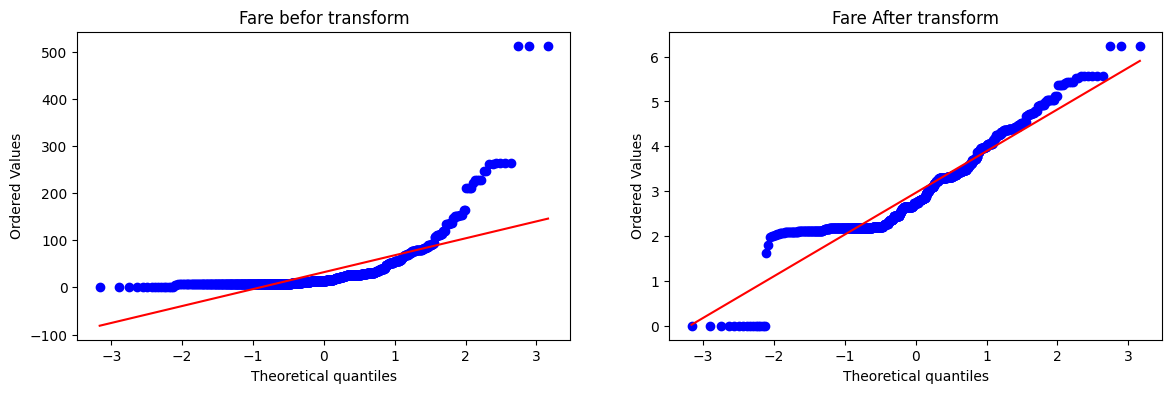

In [32]:
apply_transform(np.log1p)

# power transform

In [1]:
# import all the libraries
import numpy as np
import pandas as pd
import  matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

### 4.Box-Cox transform

In [2]:
df = pd.read_csv("DATASET/concrete_data.csv")

In [3]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [5]:
df.describe()
# output show dataset contain zero values 
# that should be problematic

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [6]:
# Train your model without transform
X =df.drop(columns=['Strength'])
y =df['Strength']

# split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)
y_pred =model.predict(X_test)
score = r2_score(y_test,y_pred)
print("Score (r2) :",score)

# apply cross val scorenp
cross = np.mean(cross_val_score(model,X,y,scoring='r2'))
print("cross val score :",cross)

Score (r2) : 0.6249829353885574
cross val score : 0.46099404916628606


/tmp/ipykernel_7463/3051949427.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


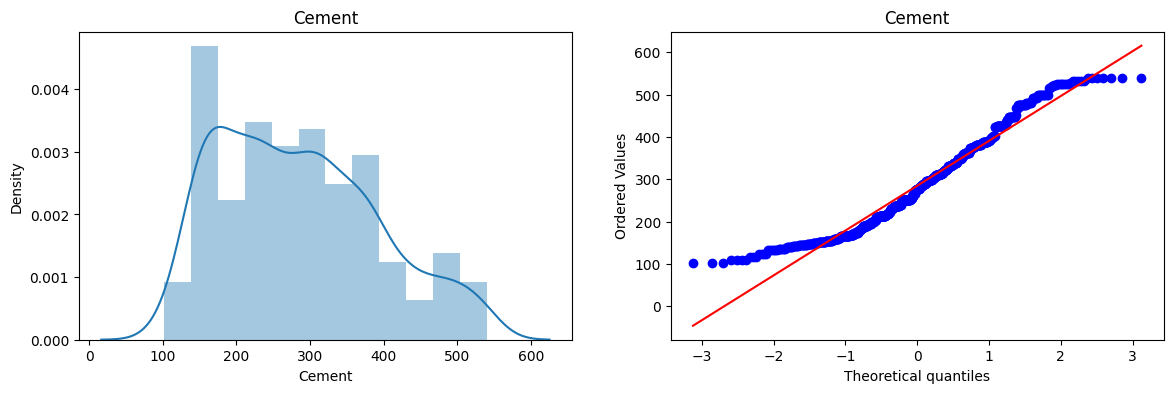

/tmp/ipykernel_7463/3051949427.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


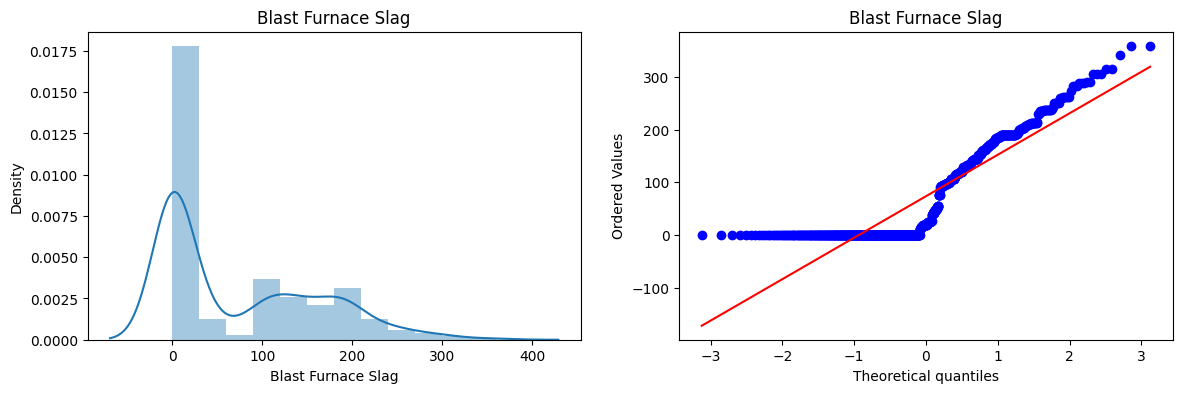

/tmp/ipykernel_7463/3051949427.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


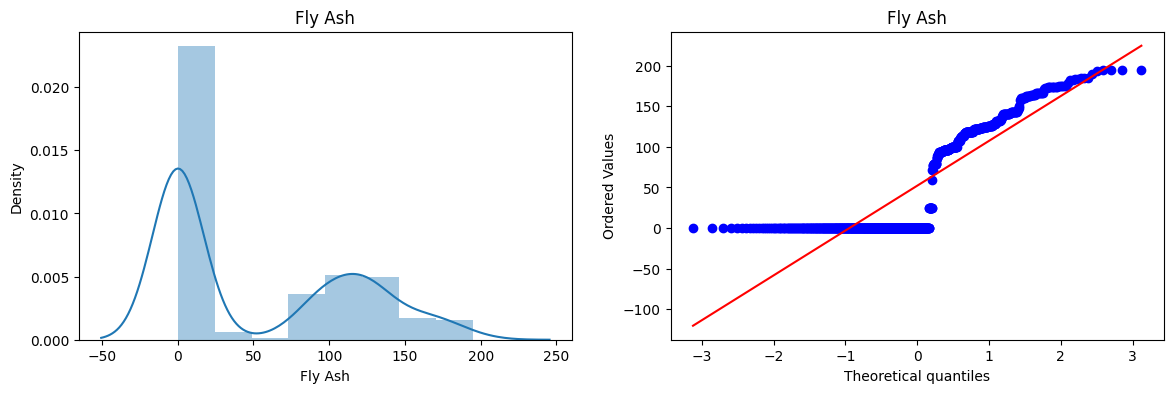

/tmp/ipykernel_7463/3051949427.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


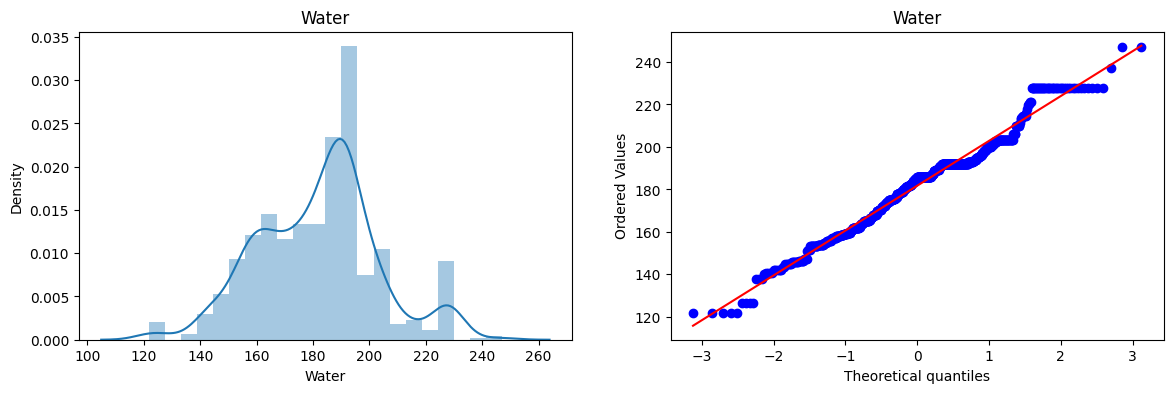

/tmp/ipykernel_7463/3051949427.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


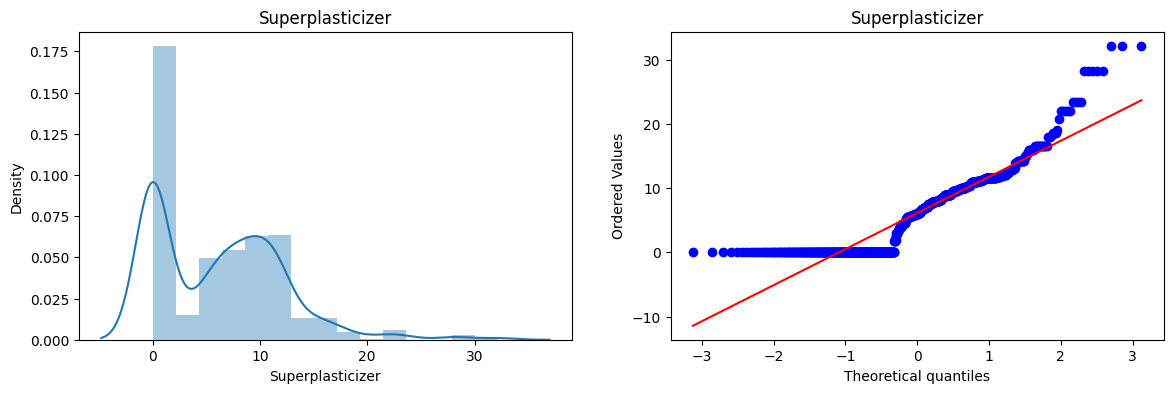

/tmp/ipykernel_7463/3051949427.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


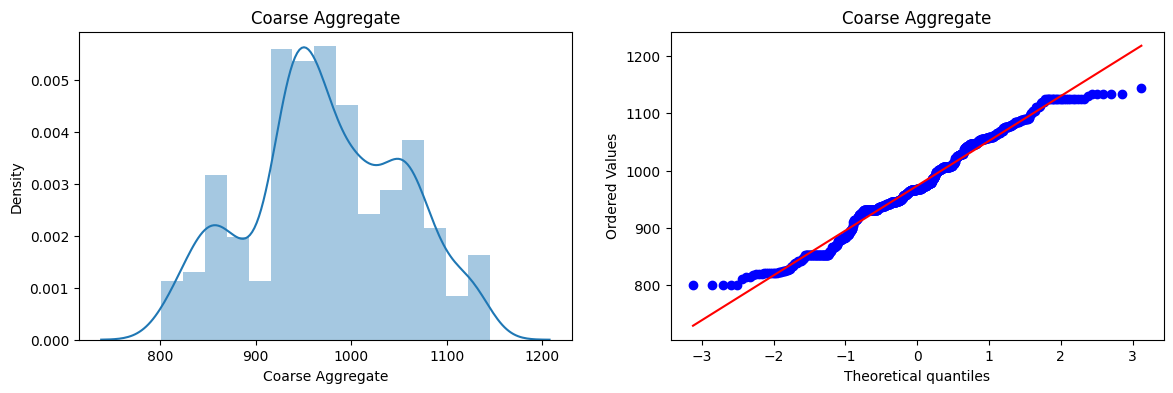

/tmp/ipykernel_7463/3051949427.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


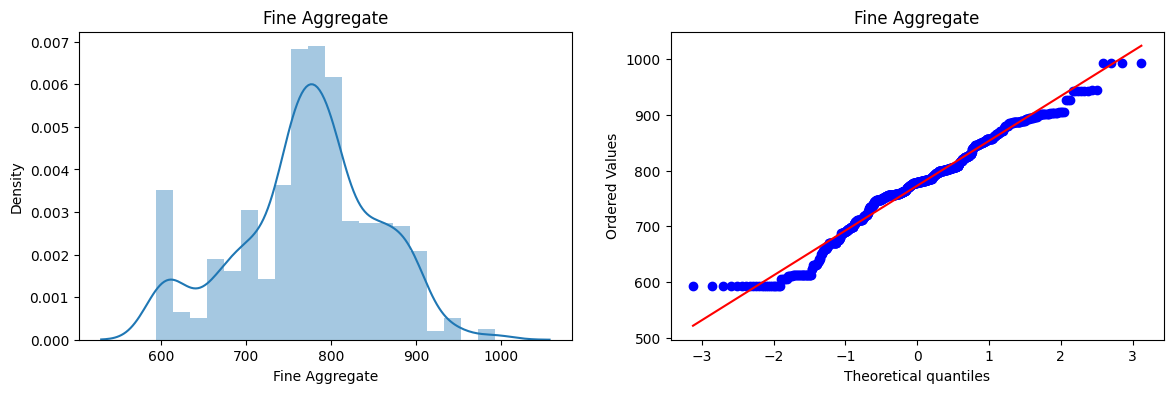

/tmp/ipykernel_7463/3051949427.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


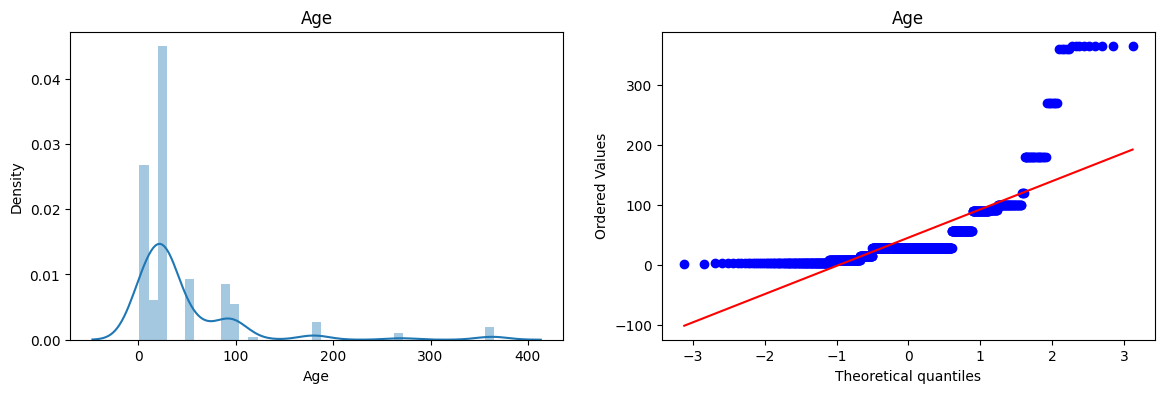

In [7]:
# plotting a distplot without any transformation
for col in X_train.columns:
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col],dist ='norm',plot =plt)
    plt.title(col)

    plt.show()

In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

# 1. Dynamically find the absolute minimum across BOTH training and testing datasets
# This ensures that no out-of-bounds value in X_test can ever drop below zero.
global_min = min(X_train.min().min(), X_test.min().min())

# 2. Compute a definitive shift value. If the absolute minimum is zero or negative,
# we shift the data so that the absolute lowest value becomes exactly 1.0.
shift_amount = abs(global_min) + 1.0 if global_min <= 0 else 0

X_train_positive = X_train + shift_amount
X_test_positive = X_test + shift_amount

# 3. Double-check for float precision edge cases and clip everything to a safe minimum of 1.0
X_train_positive = np.clip(X_train_positive, 1.0, None)
X_test_positive = np.clip(X_test_positive, 1.0, None)

# 4. Safely apply Box-Cox now that values are guaranteed to be >= 1.0 everywhere
power_transform = PowerTransformer(method='box-cox') 
X_trans = power_transform.fit_transform(X_train_positive)
X_test_tra = power_transform.transform(X_test_positive)

# 5. Print out the feature lambdas
print(pd.DataFrame({
    'col': X_train.columns, 
    'box-cox': power_transform.lambdas_
}))

# 6. Train the Model
model_tra = LinearRegression()
model_tra.fit(X_trans, y_train)

# 7. Predict and Evaluate
y_pred = model_tra.predict(X_test_tra)
print("Predictions:", y_pred)

# Corrected variable name syntax (removed the invalid space)
score = r2_score(y_test, y_pred)
print("r2 score :", score)

# 8. Cross validation evaluation (explicitly setting cv=5 folds)
cross = np.mean(cross_val_score(model_tra, X_trans, y_train, scoring='r2', cv=5))
print("Mean Cross-Val Score :", cross)


                  col   box-cox
0              Cement  0.191971
1  Blast Furnace Slag  0.000482
2             Fly Ash -0.178001
3               Water  0.850289
4    Superplasticizer  0.231695
5    Coarse Aggregate  1.126614
6      Fine Aggregate  1.860416
7                 Age  0.019683
Predictions: [53.2410582  44.96417229 64.38508736 38.91500848 14.09868591 45.36741394
 28.04787829 50.05163457 31.31297591 45.27275704 36.32888171 17.19694646
 52.57352259 39.93125125 29.08438643 26.16554508 31.22298629 22.560099
 39.49503258 28.9904554  39.71471103 30.89864925 42.80697369  8.4458851
 37.06734646 36.03784837 11.40904749 49.23852416 45.21242801 12.61133361
 40.24907451 34.84970292 41.96877066 51.58080014 17.53213413 36.56671663
 30.86201009 45.45674834  9.70096097 43.87816506 18.09861861 -0.23997284
 39.28610105 54.70445692  8.0353803  61.83339606 49.94825131 51.54043852
 25.47661226  3.83473091 45.50203423 44.68789367 26.2799745  20.01535052
 43.11906233 38.192692   25.4100075  13.88433

/tmp/ipykernel_7463/1799061379.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
/tmp/ipykernel_7463/1799061379.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


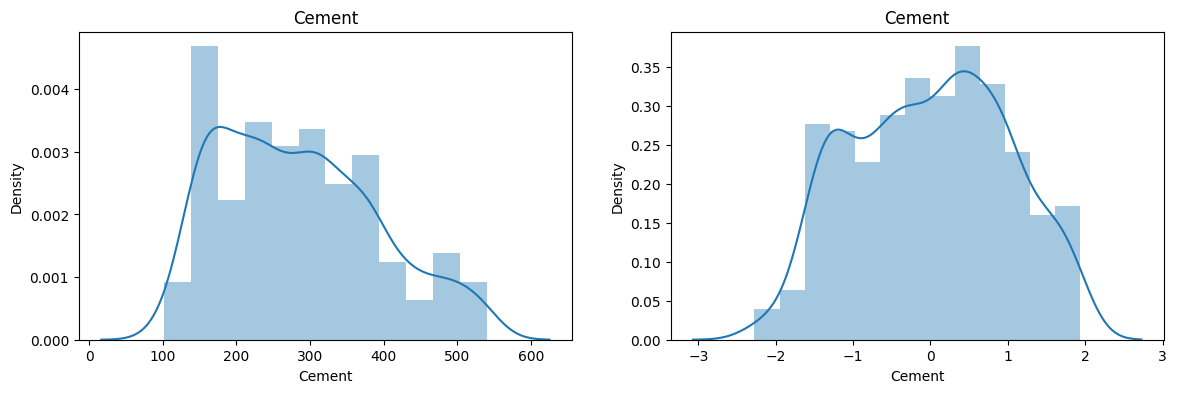

/tmp/ipykernel_7463/1799061379.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
/tmp/ipykernel_7463/1799061379.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


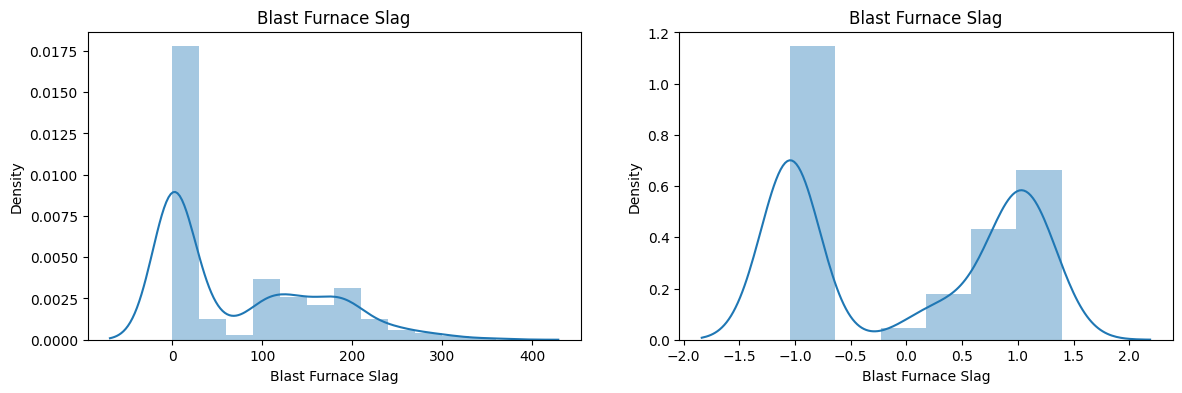

/tmp/ipykernel_7463/1799061379.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
/tmp/ipykernel_7463/1799061379.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


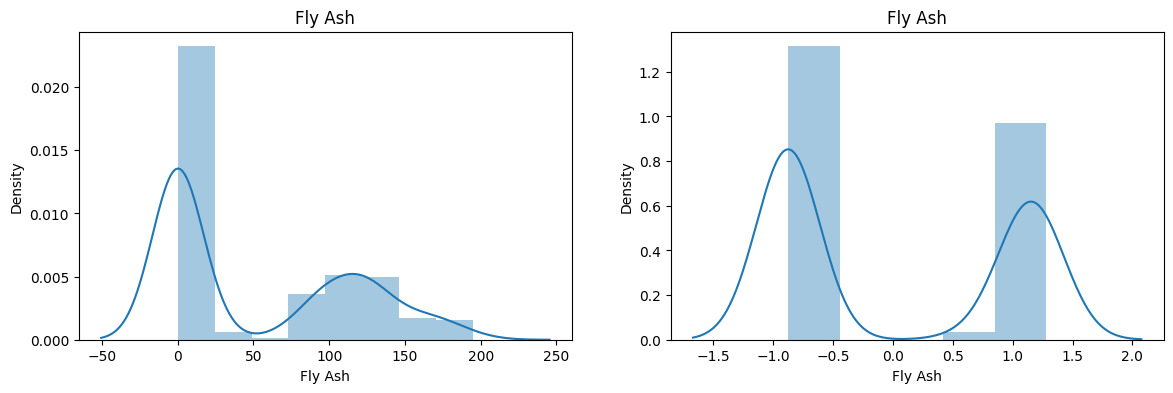

/tmp/ipykernel_7463/1799061379.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
/tmp/ipykernel_7463/1799061379.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


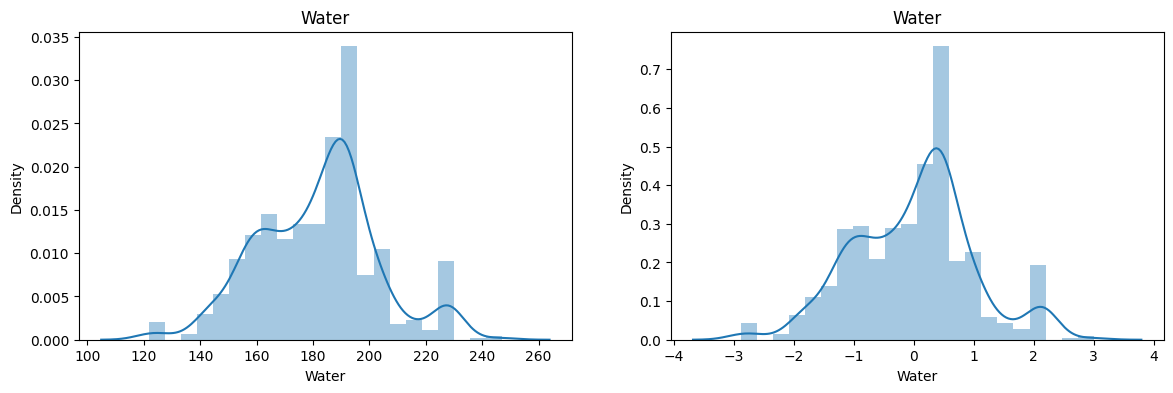

/tmp/ipykernel_7463/1799061379.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
/tmp/ipykernel_7463/1799061379.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


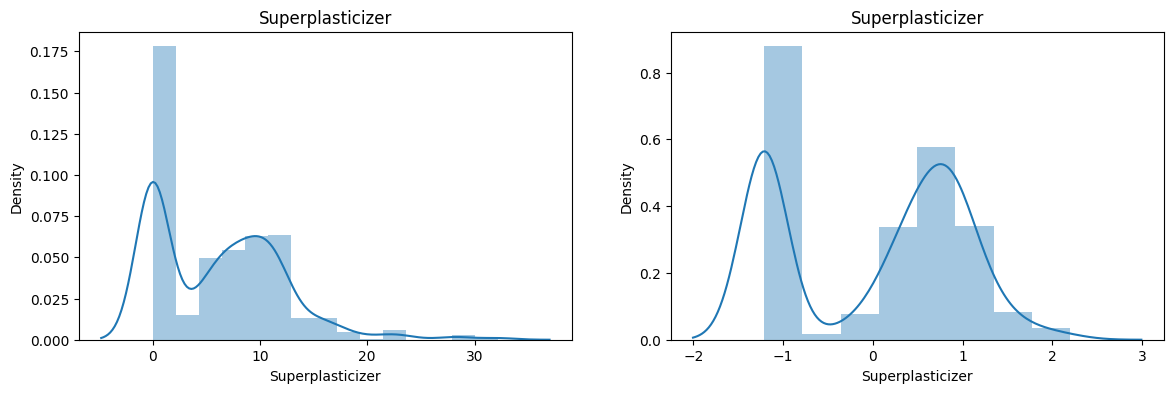

/tmp/ipykernel_7463/1799061379.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
/tmp/ipykernel_7463/1799061379.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


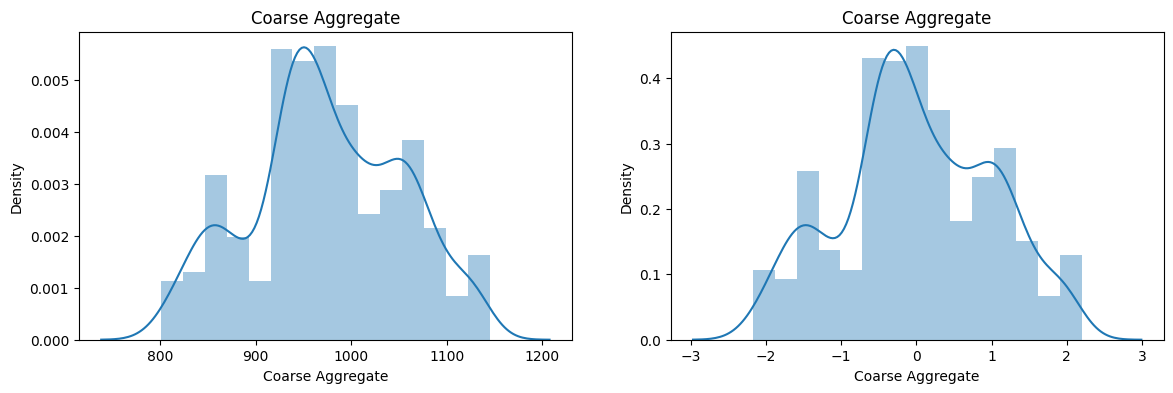

/tmp/ipykernel_7463/1799061379.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
/tmp/ipykernel_7463/1799061379.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


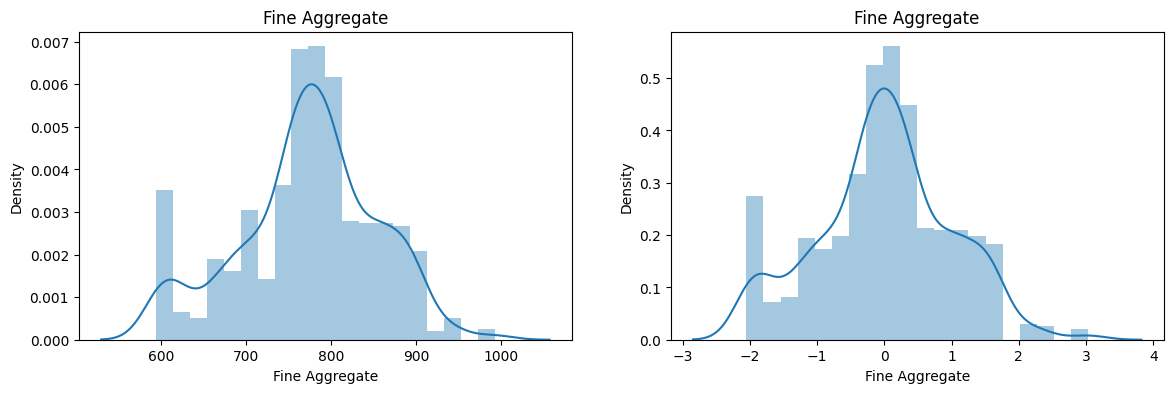

/tmp/ipykernel_7463/1799061379.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
/tmp/ipykernel_7463/1799061379.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


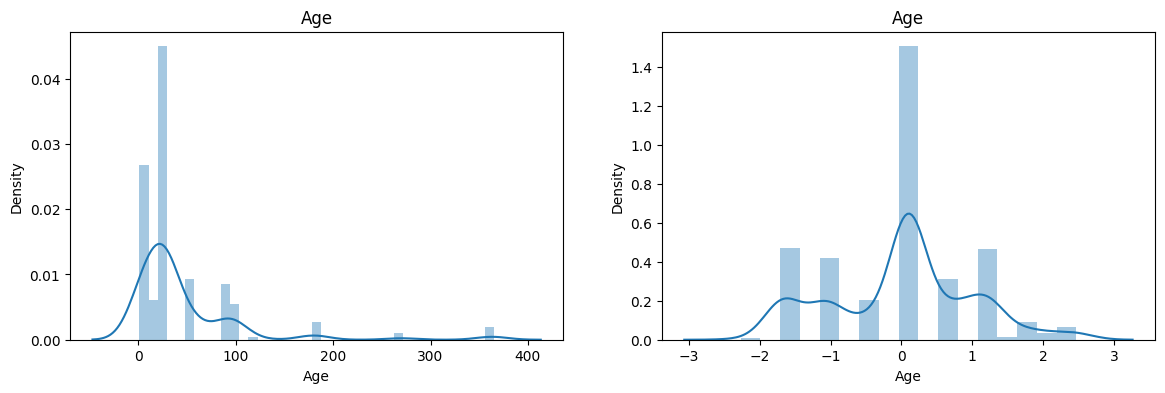

In [9]:
# Before and after comparision for Box-Cox Plot
X_train_transformed = pd.DataFrame(X_trans,columns=X_train.columns)

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.distplot(X_train_transformed[col])
    plt.title(col)

    plt.show()

### 5.Yeo-johnson transform

In [13]:
power_transform_1 = PowerTransformer()

X_train_2 =power_transform_1.fit_transform(X_train)
X_test_2 = power_transform_1.transform(X_test)

model = LinearRegression()
model.fit(X_train_2,y_train)

y_pred = model.predict(X_test_2)

print("r2 score :",r2_score(y_test,y_pred))

pd.DataFrame({'cols': X_train.columns,'yeo-johnson_lambda':power_transform_1.lambdas_})

# apply cross val score 
cross = np.mean(cross_val_score(model,X_train_2,y_train,scoring='r2',cv =15))
print('cross val score :',cross)

r2 score : 0.8075413175422108
cross val score : 0.7892021861892096


In [16]:
# dataframe
X_train_2 = pd.DataFrame(X_train_2,columns=X_train.columns)

/tmp/ipykernel_7463/681998882.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[i])
/tmp/ipykernel_7463/681998882.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_2[i])


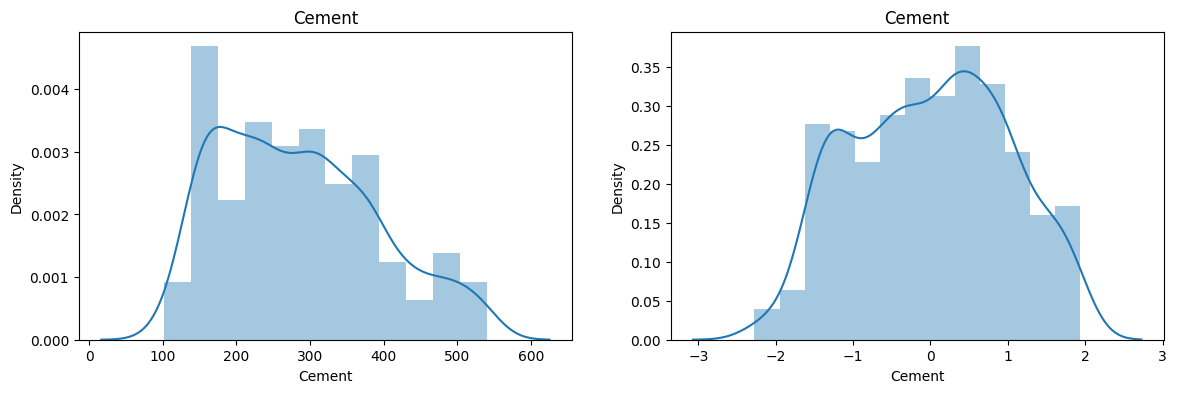

/tmp/ipykernel_7463/681998882.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[i])
/tmp/ipykernel_7463/681998882.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_2[i])


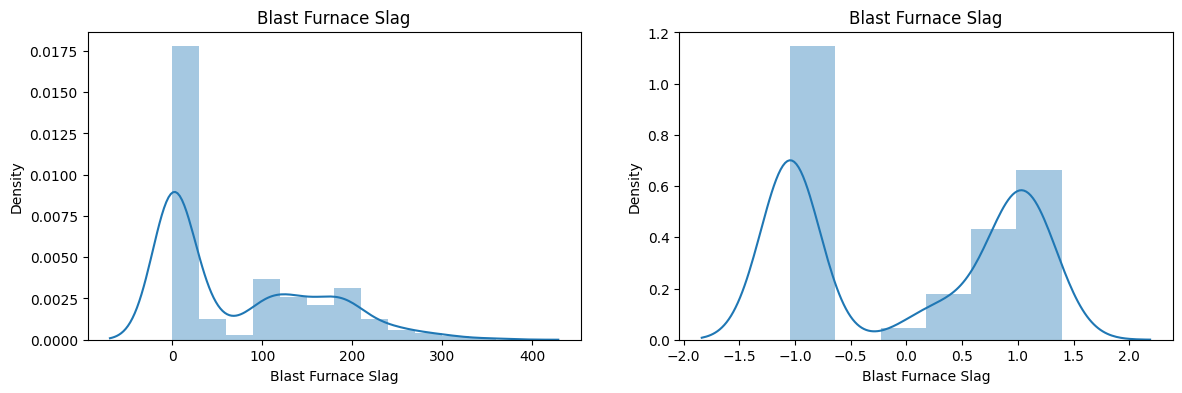

/tmp/ipykernel_7463/681998882.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[i])
/tmp/ipykernel_7463/681998882.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_2[i])


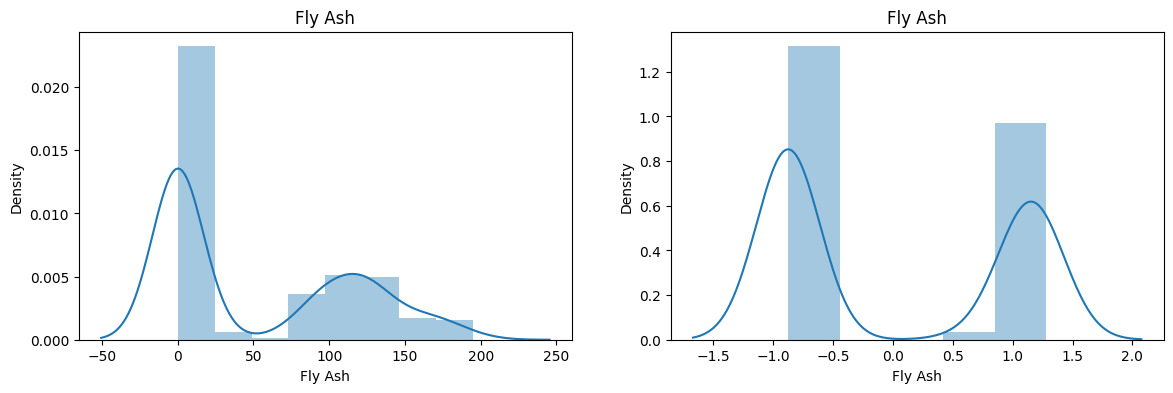

/tmp/ipykernel_7463/681998882.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[i])
/tmp/ipykernel_7463/681998882.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_2[i])


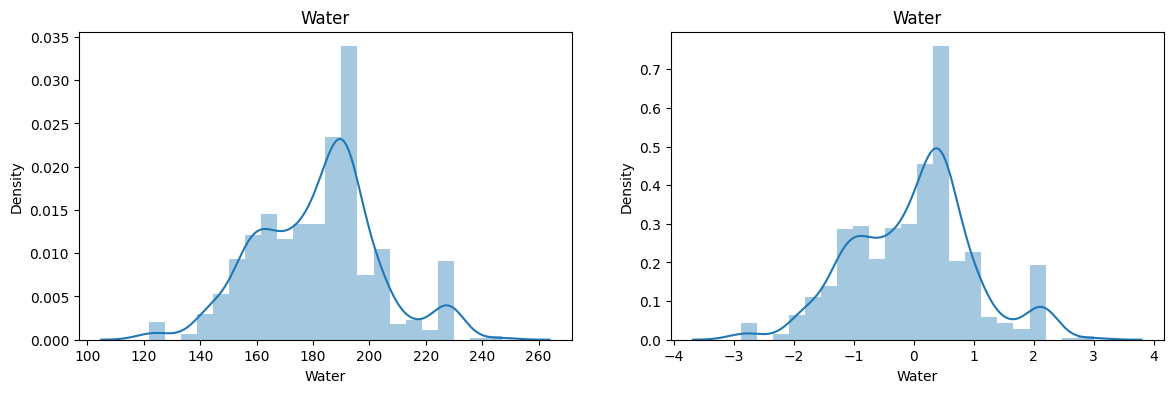

/tmp/ipykernel_7463/681998882.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[i])
/tmp/ipykernel_7463/681998882.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_2[i])


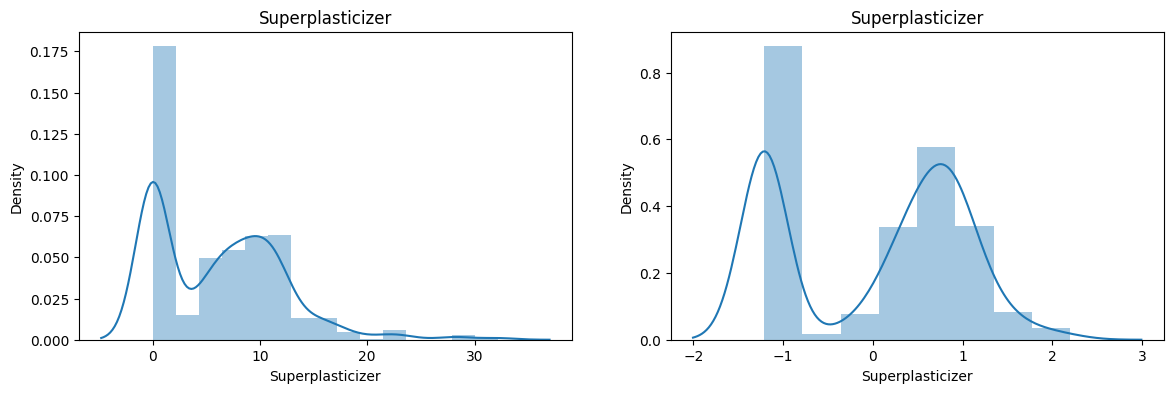

/tmp/ipykernel_7463/681998882.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[i])
/tmp/ipykernel_7463/681998882.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_2[i])


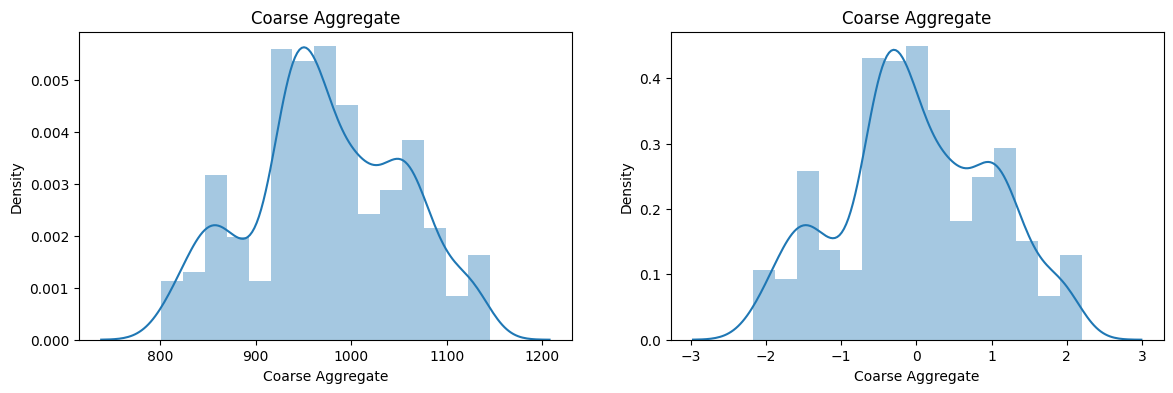

/tmp/ipykernel_7463/681998882.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[i])
/tmp/ipykernel_7463/681998882.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_2[i])


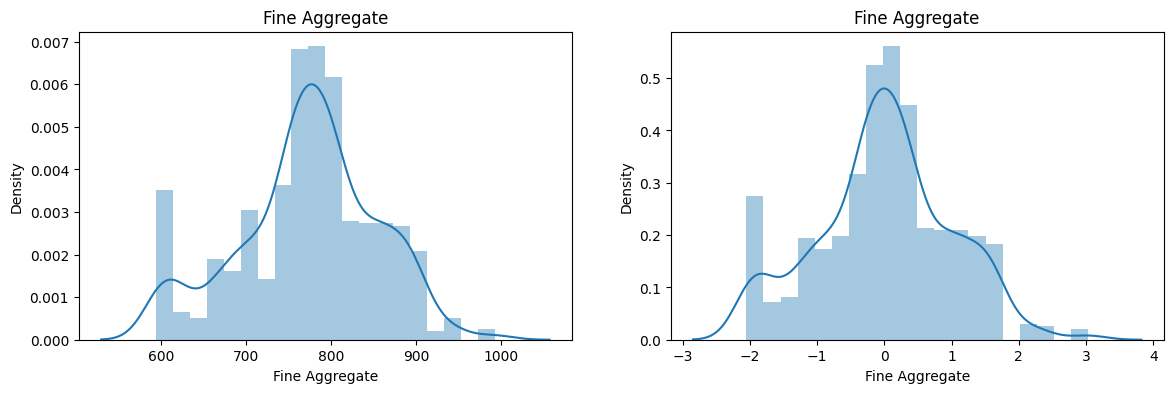

/tmp/ipykernel_7463/681998882.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[i])
/tmp/ipykernel_7463/681998882.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_2[i])


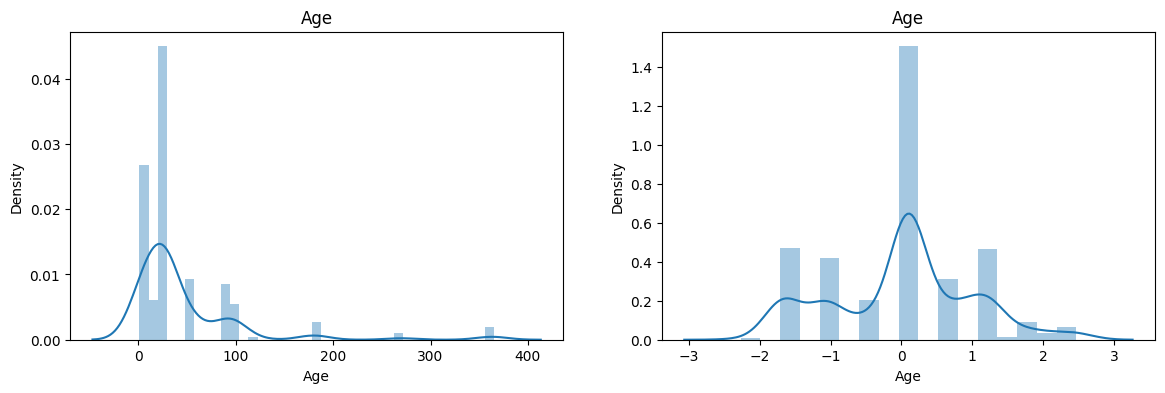

In [17]:
for i in X_train_2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[i])
    plt.title(i)

    plt.subplot(122)
    sns.distplot(X_train_2[i])
    plt.title(i)

    plt.show()

In [18]:
# compare both transformation lambda value 
pd.DataFrame({'col':X_train.columns,'box-cox':power_transform.lambdas_,'yeo-johnson':power_transform_1.lambdas_})

,col,box-cox,yeo-johnson
0,Cement,0.191971,0.191971
1,Blast Furnace Slag,0.000482,0.000482
2,Fly Ash,-0.178001,-0.178001
3,Water,0.850289,0.850289
4,Superplasticizer,0.231695,0.231695
5,Coarse Aggregate,1.126614,1.126614
6,Fine Aggregate,1.860416,1.860416
7,Age,0.019683,0.019683
